In [47]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
def getDict(file_name):
    time2signal = {}

    # open the txt file
    with open(file_name, 'r', newline='') as file:
        lines = file.readlines()
        on = False

        for line in lines:

            # switch
            if not line.strip().startswith('R.Time'):  # lines to ignore
                pass
            else:
                on = True
                continue

            # record
            if on:
                l = line.strip().split()
                if len(l) == 2:
                    time2signal[float(l[0])] = int(l[1])
                else:
                    break

    return time2signal

def plotOne(data, label=''):
    plt.plot(data.keys(), data.values()) 
    plt.xlim([0, 10])
    plt.xlabel('Retention time (min)')
    plt.ylabel('Intensity@260nm (mV)')
    plt.title(label)
    plt.show()

# day 1

In [49]:
day1_number2title = {'1': 'blank', '2': 'AMP', '3': 'ADP', '4': 'ATP', '5': 'AMP+ADP+ATP', '6': 'UMP+UDP+UTP', '7': 'CMP+CDP+CTP', '8': 'GMP+GDP+GTP'}

In [50]:
files

['/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/29.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/15.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/14.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/28.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/16.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/17.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/13.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/12.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/10.txt',
 '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation

In [4]:
folder_path = '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240804/'
files_pattern = '*.txt'
files = glob.glob(folder_path + files_pattern)

day1_data = {}  # dict of dicts

for file_name in files:
    number = file_name.split('/')[-1].split('.')[0]
    day1_data[day1_number2title[number]] = getDict(file_name)

In [5]:
len(day1_data)

8

In [6]:
day1_data.keys()

dict_keys(['GMP+GDP+GTP', 'AMP+ADP+ATP', 'ATP', 'UMP+UDP+UTP', 'CMP+CDP+CTP', 'ADP', 'AMP', 'blank'])

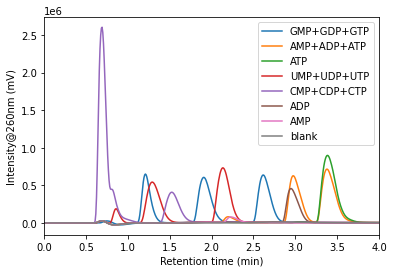

In [36]:
for key, data in day1_data.items():
    plt.plot(data.keys(), data.values(), label=key)

plt.legend() 
plt.xlim([0, 4])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')  # 260nm for base
plt.savefig('day1_control_all_substrates_HPLC.png', dpi=300, bbox_inches='tight')
plt.show()

# why is [AMP] low? lower stock conc.?
# for better seprataion, use different buffer, pH etc. to tweak hydrophobicity of substrate

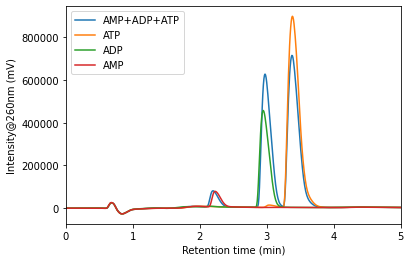

In [37]:
for key, data in day1_data.items():
    if 'A' in key:
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()    
plt.xlim([0, 5])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day1_control_adenosines.png', dpi=300, bbox_inches='tight')
plt.show()

# day 2

In [9]:
day2_number2title = {'1': 'Mn 37degC (-)protein(+)AMP+ADP+ATP', '2': 'Mn 37degC (-)protein(-)substrate', '3': 'Mn 37degC AMP', '4': 'Mn 37degC ADP', '5': 'Mn 37degC ATP', '6': 'Mn 45degC AMP', '7': 'Mn 45degC ADP', '8': 'Mn 45degC ATP', '9': 'Mn 50degC AMP', '10': 'Mn 50degC ADP', '11': 'Mn 50degC ATP', '12': 'Mn 55degC AMP', '13': 'Mn 55degC ADP', '14': 'Mn 55degC ATP', '15': 'Mn 60degC AMP', '16': 'Mn 60degC ADP', '17': 'Mn 60degC ATP'
, '18': 'Co 37degC (-)protein(+)AMP+ADP+ATP', '19': 'Co 37degC (-)protein(-)substrate', '20': 'Co 37degC AMP', '21': 'Co 37degC ADP', '22': 'Co 37degC ATP', '23': 'Co 45degC AMP', '24': 'Co 45degC ADP', '25': 'Co 45degC ATP', '26': 'Co 50degC AMP', '27': 'Co 50degC ADP', '28': 'Co 50degC ATP', '29': 'Co 55degC AMP', '30': 'Co 55degC ADP', '31': 'Co 55degC ATP', '32': 'Co 60degC AMP', '33': 'Co 60degC ADP', '34': 'Co 60degC ATP'}

In [10]:
folder_path = '/Users/tseamuscorlett/Desktop/M1_courses/Lab_Rotation/lab_rotation_tomo/PolyP_MAN_HPLC/240806/'
files_pattern = '*.txt'
files = glob.glob(folder_path + files_pattern)

day2_data = {}

for file_name in files:
    number = file_name.split('/')[-1].split('.')[0]
    day2_data[day2_number2title[number]] = getDict(file_name)

In [11]:
day2_data.keys()

dict_keys(['Co 55degC AMP', 'Mn 60degC AMP', 'Mn 55degC ATP', 'Co 50degC ATP', 'Mn 60degC ADP', 'Mn 60degC ATP', 'Mn 55degC ADP', 'Mn 55degC AMP', 'Mn 50degC ADP', 'Mn 50degC ATP', 'Mn 50degC AMP', 'Mn 45degC ATP', 'Mn 37degC ATP', 'Mn 37degC ADP', 'Mn 45degC AMP', 'Mn 45degC ADP', 'Mn 37degC AMP', 'Mn 37degC (-)protein(-)substrate', 'Mn 37degC (-)protein(+)AMP+ADP+ATP', 'Co 60degC ATP', 'Co 37degC AMP', 'Co 37degC ADP', 'Co 45degC AMP', 'Co 37degC ATP', 'Co 50degC AMP', 'Co 60degC AMP', 'Co 60degC ADP', 'Co 50degC ADP', 'Co 55degC ATP', 'Co 45degC ATP', 'Co 37degC (-)protein(-)substrate', 'Co 37degC (-)protein(+)AMP+ADP+ATP', 'Co 45degC ADP', 'Co 55degC ADP'])

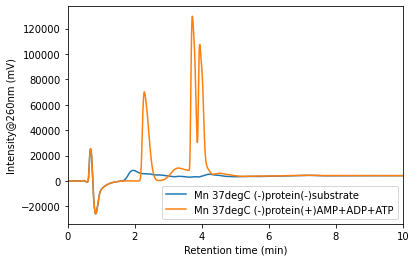

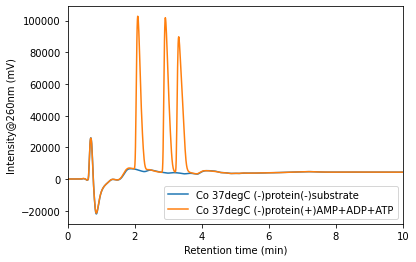

In [38]:
for key, data in day2_data.items():
    if '-' in key and 'Mn' in key:
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()    
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_control_Mn.png', dpi=300, bbox_inches='tight')
plt.show()


for key, data in day2_data.items():
    if '-' in key and 'Co' in key:
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()    
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_control_Co.png', dpi=300, bbox_inches='tight')
plt.show()

## Mn

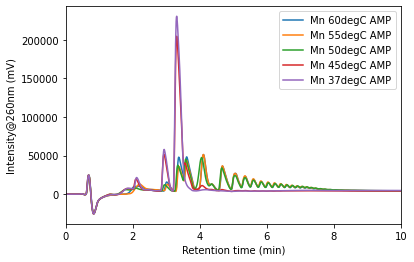

In [39]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and ks[2] == 'AMP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Mn_AMP.png', dpi=300, bbox_inches='tight')
plt.show()

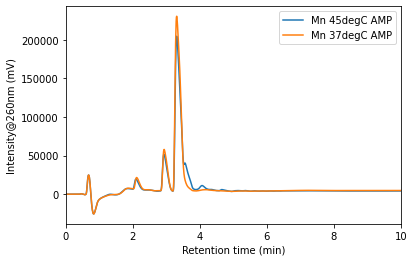

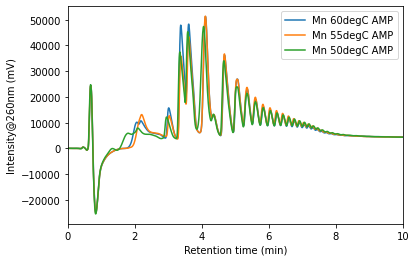

In [40]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and int(ks[1][0:2]) < 50 and ks[2] == 'AMP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Mn_AMP_37_45.png', dpi=300, bbox_inches='tight')
plt.show()

for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and int(ks[1][0:2]) >= 50 and ks[2] == 'AMP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Mn_AMP_50_55_60.png', dpi=300, bbox_inches='tight')
plt.show()

# AMP is stable at 60 => polymerization is probably still enzyme dependent

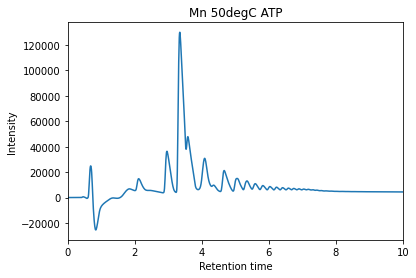

In [15]:
k = 'Mn 50degC ATP'
plotOne(day2_data[k], label=k)

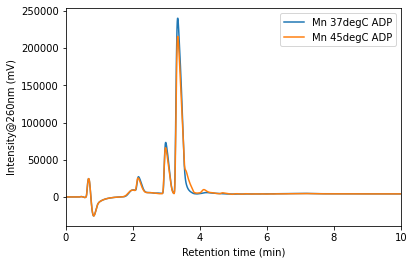

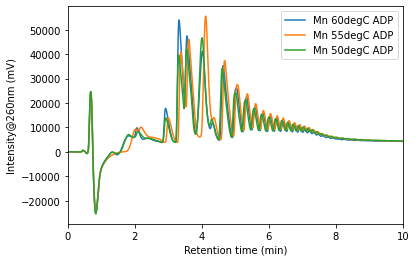

In [41]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and int(ks[1][0:2]) < 50 and ks[2] == 'ADP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Mn_ADP_37_45.png', dpi=300, bbox_inches='tight')
plt.show()

for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and int(ks[1][0:2]) >= 50 and ks[2] == 'ADP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Mn_ADP_50_55_60.png', dpi=300, bbox_inches='tight')
plt.show()

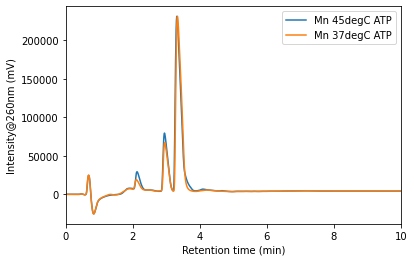

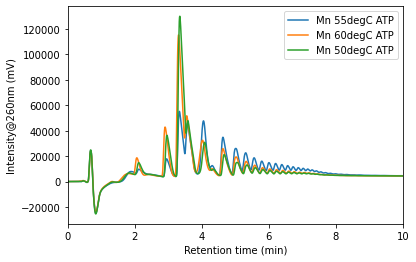

In [42]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and int(ks[1][0:2]) < 50 and ks[2] == 'ATP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Mn_ATP_37_45.png', dpi=300, bbox_inches='tight')
plt.show()

for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and int(ks[1][0:2]) >= 50 and ks[2] == 'ATP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Mn_ATP_50_55_60.png', dpi=300, bbox_inches='tight')
plt.show()

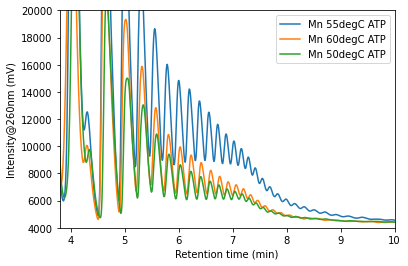

In [43]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and int(ks[1][0:2]) >= 50 and ks[2] == 'ATP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([3.8, 10])
plt.ylim([4000, 20000])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Mn_ATP_50_55_60_zoom.png', dpi=300, bbox_inches='tight')
plt.show()

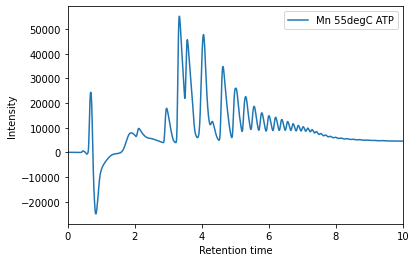

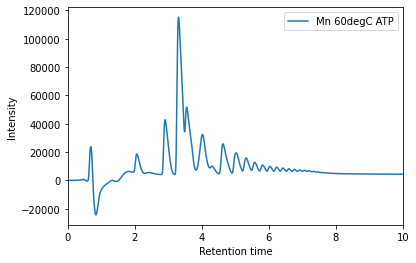

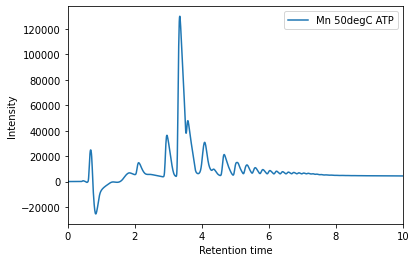

In [18]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Mn' and int(ks[1][0:2]) >= 50 and ks[2] == 'ATP':
        plt.plot(data.keys(), data.values(), label=key)

        plt.legend()
        plt.xlim([0, 10])
        plt.xlabel('Retention time (min)')
        plt.ylabel('Intensity@260nm (mV)')
        plt.show()

## Co

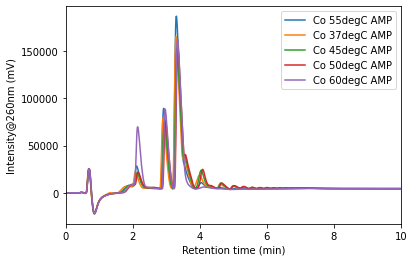

In [44]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Co' and ks[2] == 'AMP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Co_AMP.png', dpi=300, bbox_inches='tight')
plt.show()

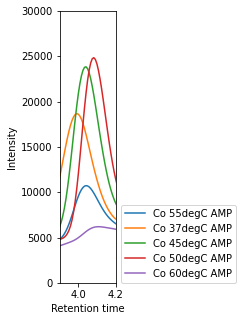

In [20]:
plt.figure(figsize=(1, 5))
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Co' and ks[2] == 'AMP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend(loc=(1.1, 0))  
plt.xlim([3.9, 4.2])
plt.ylim([0, 30000])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.show()

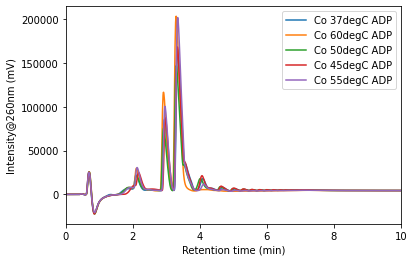

In [45]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Co' and ks[2] == 'ADP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Co_ADP.png', dpi=300, bbox_inches='tight')
plt.show()

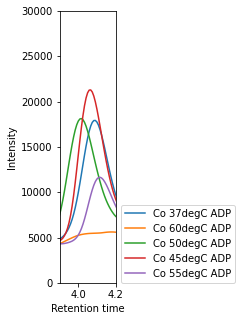

In [22]:
plt.figure(figsize=(1, 5))
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Co' and ks[2] == 'ADP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend(loc=(1.1, 0))  
plt.xlim([3.9, 4.2])
plt.ylim([0, 30000])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.show()

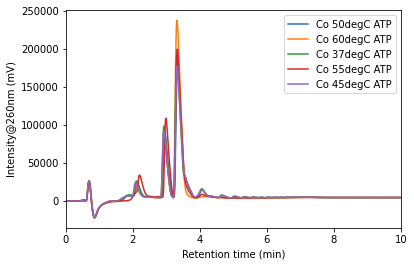

In [46]:
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Co' and ks[2] == 'ATP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend()  
plt.xlim([0, 10])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.savefig('day2_Co_ATP.png', dpi=300, bbox_inches='tight')
plt.show()

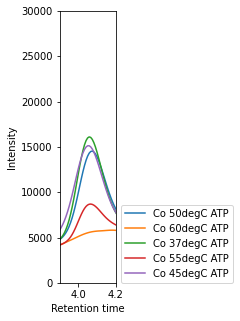

In [24]:
plt.figure(figsize=(1, 5))
for key, data in day2_data.items():
    ks = key.split()
    if ks[0] == 'Co' and ks[2] == 'ATP':
        plt.plot(data.keys(), data.values(), label=key)

plt.legend(loc=(1.1, 0))  
plt.xlim([3.9, 4.2])
plt.ylim([0, 30000])
plt.xlabel('Retention time (min)')
plt.ylabel('Intensity@260nm (mV)')
plt.show()